# Non-parametric Piecing-Together Pair-Copula Density Estimation
In this notebook, we investigate three different types of non-parametric pari-copula density estimation:
- Standard TLL on the entire unit square
- Hard PT-approach: Piecing-together five copula densities using a chosen threshold
- Smooth blending: Divide the area in four partitions and do a smooth blending between bulk and tail estimations.


In [ ]:
!pip install pyvinecopulib

In [ ]:
import os
import torch
from torch import Tensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np
import pyvinecopulib as pv
from matplotlib.colors import LogNorm
from scipy.stats import rankdata
import math

seed = 97

# To match pyvinecopulib
torch.set_default_dtype(torch.float64)

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Optional, for stricter GPU determinism
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False


SQRT_2PI_INV = 1.0 / torch.sqrt(torch.tensor(2.0 * torch.pi))

### Use functions as in `pyvinecopulib`

In [ ]:
def qnorm(p):
    return torch.special.ndtri(p)


def dnorm(z):
    return torch.exp(-0.5 * z * z) * SQRT_2PI_INV



def fit_local_likelihood_constant(z_eval, z_data, B):
    """
    z_eval:  (m*m, 2) evaluation points on probit scale
    z_data:  (n, 2) transformed data on probit scale
    B:       (2, 2) bandwidth matrix

    returns: (m*m,) estimated density f_ST at z_eval
    """
    L = torch.linalg.cholesky(B)
    inv_L = torch.linalg.inv(L)
    det_inv_L = torch.linalg.det(inv_L)

    z_eval_std = (inv_L @ z_eval.T).T
    z_data_std = (inv_L @ z_data.T).T

    diff = z_data_std.unsqueeze(0) - z_eval_std.unsqueeze(1)

    kernel_values = (
        torch.exp(-0.5 * (diff[..., 0] ** 2 + diff[..., 1] ** 2))
        * SQRT_2PI_INV
        * SQRT_2PI_INV
        * det_inv_L
    )

    return kernel_values.mean(dim=1)

#### Simulation setup

In [ ]:
# Integration grid
grid_size = 50
eps_grid = 1e-4
u_1d = torch.linspace(eps_grid, 1 - eps_grid, grid_size)
u_grid = torch.cartesian_prod(u_1d, u_1d)
cell_area = (u_1d[1] - u_1d[0]) ** 2
z_grid = qnorm(u_grid)

# Sample size and lower-tail cutoff
n = 2000 # [100, 200, 1000, 2000]
q = n ** (-1/2)  # lower-tail cutoff

# Tail integration grid
u_tail_grid = u_grid * q
cell_area_tail = (q ** 2) * cell_area
z_tail_grid = qnorm(u_tail_grid)

### Sample data

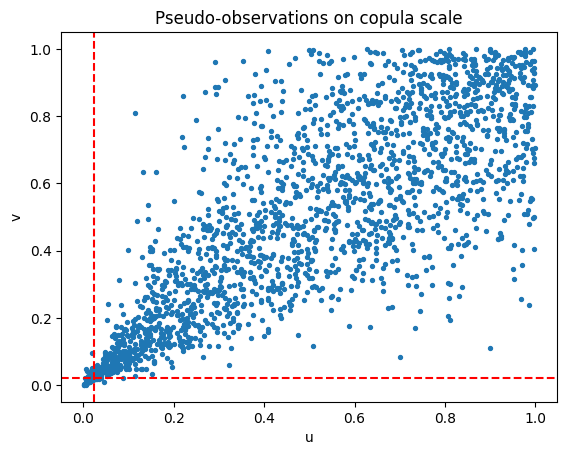

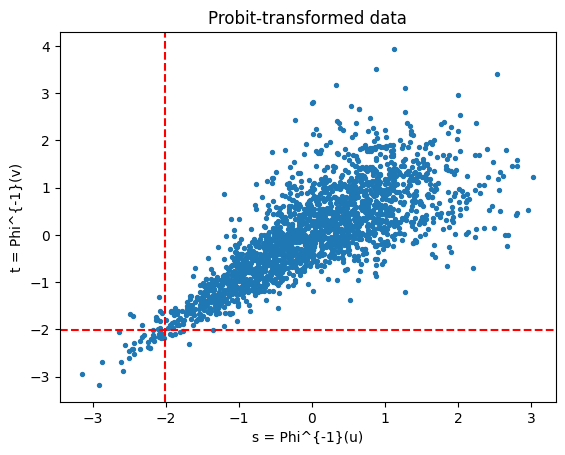

In [ ]:
theta = 3.0  # larger = stronger lower-tail dependence

# ktau in [0.4, 0.8] => copula parameter
# clayton, gumbel, student, gaussian
# ~10 seeds

bicop = pv.Bicop(
    family=pv.BicopFamily.clayton, rotation = 0,
    parameters=np.array([[theta]], dtype=float),
)

u_data_np = bicop.simulate(n, seeds = [seed])
u_data = torch.tensor(u_data_np, dtype=torch.float64)

z_data = qnorm(u_data.clamp(1e-6, 1 - 1e-6))

# %%
plt.figure()
plt.scatter(u_data[:, 0], u_data[:, 1], s=8)
plt.title("Pseudo-observations on copula scale")
plt.xlabel("u")
plt.ylabel("v")
plt.axvline(x=q, color="r", linestyle="--")
plt.axhline(y=q, color="r", linestyle="--")
plt.show()

# %%
plt.figure()
plt.scatter(z_data[:, 0], z_data[:, 1], s=8)
plt.title("Probit-transformed data")
plt.xlabel("s = Phi^{-1}(u)")
plt.ylabel("t = Phi^{-1}(v)")
plt.axvline(x=qnorm(torch.tensor(q)), color="r", linestyle="--")
plt.axhline(y=qnorm(torch.tensor(q)), color="r", linestyle="--")
plt.show()

Looks correct!
### Bandwith selection

Let's define the bandwidth according to the covariance of the data according to
\begin{align*}
B_{\text{tail}} = h_{\text{tail}} \Sigma_{\text{tail}} + \varepsilon I.
\end{align*}
The remaining question here is: how do we choose the scaling factor $h_{\text{tail}}$? A simple rule is to use the sample size $k$ in the tail, i.e., in the area of $[0,q]^2$:
\begin{align*}
    h_{\text{tail}} =  k^{-\frac{2}{6}}.
\end{align*}

Compare this bandwidth with the actual TLL bandwidth implemented in pyvinecopulib:

In [ ]:
def _pearson_cor(x: Tensor) -> Tensor:
  """Pearson correlation of two columns of ``x: (n, 2)``. Returns a 0-D tensor."""
  x0 = x[:, 0] - x[:, 0].mean()
  x1 = x[:, 1] - x[:, 1].mean()
  return (x0 * x1).sum() / ((x0**2).sum().sqrt() * (x1**2).sum().sqrt())


def _pairwise_mcor(x: Tensor) -> float:
  """Maximal correlation via ACE + Pearson. Returns a Python float."""
  phi = _ace(x)
  return _pearson_cor(phi).item()


def _win_smoother(x: Tensor, wl: int) -> Tensor:
  """Centered moving average of half-window ``wl``, with edge clamps.

  Mirrors ``tools_stats::win`` semantically: pad ``x`` with ``wl`` zeros
  on each side, convolve with a uniform kernel of length ``2*wl + 1``,
  then clamp the leading / trailing ``wl`` entries to ``out[wl]`` and
  ``out[n - wl - 1]`` so the edges are flat. C++ uses FFT for the
  convolution; we use ``F.conv1d`` here for portability — same
  mathematical answer, possibly different rounding order at ~ulp level.
  """
  n = x.shape[0]
  weight = torch.full(
    (1, 1, 2 * wl + 1), 1.0 / (2 * wl + 1), dtype=x.dtype, device=x.device
  )
  x_padded = F.pad(x.view(1, 1, n), (wl, wl))
  out = F.conv1d(x_padded, weight).view(n).clone()
  if wl > 0:
    out[:wl] = out[wl]
    out[-wl:] = out[n - wl - 1]
  return out

def _cef(x: Tensor, ind: Tensor, ranks: Tensor, wl: int) -> Tensor:
  """``cef`` helper: ``win(x[ind], wl)[ranks]``.

  Smooths ``x`` in sorted order, then maps back to the original order.
  Mirrors ``tools_stats::cef``.
  """
  return _win_smoother(x[ind], wl)[ranks]

def _ace(
  data: Tensor,
  *,
  outer_iter_max: int = 100,
  inner_iter_max: int = 10,
  outer_abs_tol: float = 2e-15,
  inner_abs_tol: float = 1e-4,
) -> Tensor:
  """Alternating conditional expectations.

  Mirrors ``tools_stats::ace`` for the unweighted bivariate case (the
  only one that the TLL ``constant`` bandwidth path needs).

  Args:
    data: shape ``(n, 2)``.

  Returns:
    ``(n, 2)`` tensor of the ACE-transformed scores ``phi``.
  """
  n = data.shape[0]
  dtype, device = data.dtype, data.device
  wl = int(math.ceil(n / 5.0))

  ind = torch.empty(n, 2, dtype=torch.long, device=device)
  ranks = torch.empty(n, 2, dtype=torch.long, device=device)
  for i in range(2):
    order = data[:, i].argsort(stable=True)
    ind[:, i] = order
    ranks[order, i] = torch.arange(n, device=device)

  phi = ranks.to(dtype).clone()
  phi -= (n - 1) / 2.0 - 1.0
  phi /= math.sqrt(n * (n - 1) / 12.0)

  outer_iter, outer_eps, outer_abs_err = 1, 1.0, 1.0
  while outer_iter <= outer_iter_max and outer_abs_err > outer_abs_tol:
    inner_iter, inner_eps, inner_abs_err = 1, 1.0, 1.0
    while inner_iter <= inner_iter_max and inner_abs_err > inner_abs_tol:
      phi[:, 1] = _cef(phi[:, 0], ind[:, 1], ranks[:, 1], wl)
      phi[:, 1] = phi[:, 1] - phi[:, 1].sum() / n
      phi[:, 1] = phi[:, 1] / ((phi[:, 1] ** 2).sum() / (n - 1)).sqrt()
      prev = inner_eps
      inner_eps = ((phi[:, 1] - phi[:, 0]) ** 2).sum().item() / n
      inner_abs_err = abs(prev - inner_eps)
      inner_iter += 1
    phi[:, 0] = _cef(phi[:, 1], ind[:, 0], ranks[:, 0], wl)
    phi[:, 0] = phi[:, 0] - phi[:, 0].sum() / n
    phi[:, 0] = phi[:, 0] / ((phi[:, 0] ** 2).sum() / (n - 1)).sqrt()
    prev = outer_eps
    outer_eps = ((phi[:, 1] - phi[:, 0]) ** 2).sum().item() / n
    outer_abs_err = abs(prev - outer_eps)
    outer_iter += 1

  return phi

In [ ]:
def _select_bandwidth_constant(z: Tensor) -> Tensor:
  """Bandwidth matrix for the constant-method local-likelihood KDE.

  Mirrors ``TllBicop::select_bandwidth`` for ``method == "constant"``.
  """
  n = z.shape[0]
  cor = _pearson_cor(z).clamp(-0.95, 0.95).item()
  cov = torch.tensor([[1.0, cor], [cor, 1.0]], dtype=z.dtype, device=z.device)
  mult = n ** (-1.0 / 3.0)
  mcor = _pairwise_mcor(z)
  scale = abs(cor / mcor) ** (0.5 * mcor)
  return mult * cov * scale

## Approach 1: Standard TLL

In [ ]:
# Fit the standard TLL estimator
B_body = _select_bandwidth_constant(z_data)
f_body = fit_local_likelihood_constant(z_tail_grid, z_data, B_body)
phi_body = dnorm(z_tail_grid[:, 0]) * dnorm(z_tail_grid[:, 1])

# Estimation targets
c_body = f_body / phi_body                       # copula density in the tail
p_body = (c_body.sum() * cell_area_tail).item()  # probability mass in lower tail
r_body = q * c_body                              # tail copula density
h_body = (q**2 / p_body) * c_body                # conditional density on [0, 1]^2

## Approach 2: Tail TLL with transformed input

In [ ]:
def sample_covariance_2d(x: torch.Tensor) -> torch.Tensor:
    """
    2x2 sample covariance matrix
    """
    x_centered = x - x.mean(dim=0, keepdim=True)
    cov = (x_centered.T @ x_centered) / max(x.shape[0] - 1, 1)
    return cov

In [ ]:
# Extract data from the tail and get the tail mass
u_tail_mask = (u_data[:, 0] <= q) & (u_data[:, 1] <= q)
u_data_tail = u_data[u_tail_mask]
k = u_data_tail.shape[0]

# Rescale lower-left tail block to [0,1]^2
s_data = (u_data_tail / q).clamp(1e-6, 1 - 1e-6)
s_grid = (u_tail_grid / q).clamp(1e-6, 1 - 1e-6)

# Transform rescaled tail observations
zs_data = qnorm(s_data)
zs_grid = qnorm(s_grid)

# Bandwidth selection
# B_tail = (k ** (-2.0 / 6.0)) * sample_covariance_2d(zs_data) + 1e-6 * torch.eye(
#             2, dtype=zs_data.dtype, device=zs_data.device
# )
B_tail = _select_bandwidth_constant(zs_data)

# Fit on tail-rescaled data
f_tail = fit_local_likelihood_constant(
            zs_grid,
            zs_data,
            B_tail,
)
phi_tail = dnorm(zs_grid[:, 0]) * dnorm(zs_grid[:, 1])

# Estimation targets
p_tail = k / n                        # probability mass in lower tail
h_tail = f_tail / phi_tail            # conditional density on [0, 1]^2
c_tail = (p_tail / q**2) * h_tail     # copula density approximation in the tail
r_tail = q * c_tail                   # tail copula density

## Comparison with true copula density

In [ ]:
c_true = torch.tensor(bicop.pdf(u_tail_grid.numpy()))
r_true = q * c_true
p_true = bicop.cdf(np.array([[q, q]]))[0]
h_true = (q**2 / torch.tensor(p_true)) * c_true

In [ ]:
def grid_metrics_density(
    est: torch.Tensor,
    truth: torch.Tensor,
    cell_area: float,
    eps: float = 1e-12,
) -> dict[str, float]:
    """Integrated density errors.
    """
    est_pos = est.clamp_min(eps)
    truth_pos = truth.clamp_min(eps)

    ise = ((est - truth) ** 2).sum() * cell_area
    iae = (est - truth).abs().sum() * cell_area
    kl = (truth_pos * (truth_pos / est_pos).log()).sum() * cell_area

    return {
        "ISE": float(ise.item()),
        "IAE": float(iae.item()),
        "KL": float(kl.item()),
    }

In [ ]:
import pandas as pd

ests = {
    "Ordinary": {
        # "r": r_body,
        "h": h_body,
        "c": c_body,
    },
    "Tail": {
        # "r": r_tail,
        "h": h_tail,
        "c": c_tail,
    },
}

truths = {
    # "r": r_true,
    "h": h_true,
    "c": c_true,
}

cell_areas = {
    # "r": cell_area,
    "h": cell_area,
    "c": cell_area_tail,
}

results = []

for model, model_ests in ests.items():
    for target, est in model_ests.items():
        metrics = grid_metrics_density(
            est=est,
            truth=truths[target],
            cell_area=cell_areas[target],
        )
        results.append({
            "model": model,
            "target": target,
            **metrics,
        })

results_df = (
    pd.DataFrame(results)
    .pivot(index="model", columns="target", values=["ISE", "IAE", "KL"])
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1, level=0)

)


p_df = pd.DataFrame(
    {
        "Ordinary": {
            # "hat": p_body,
            "AE": abs(p_body - p_true),
            "RE": abs(p_body - p_true) / p_true,
        },
        "Tail": {
            # "hat": p_tail,
            "AE": abs(p_tail - p_true),
            "RE": abs(p_tail - p_true) / p_true,
        },
    }
).T

p_df.index.name = "model"
p_df.columns = pd.MultiIndex.from_product([["p"], p_df.columns])

results_df = pd.concat([results_df, p_df], axis=1)
results_df

c                                 h                           \
               IAE           ISE        KL       IAE           ISE         KL   
model                                                                           
Ordinary  0.079868  26227.499079  1.009697  4.492200  41633.350632  56.620355   
Tail      0.081002  26063.691784  0.431305  4.563918  41353.654736  23.925724   

                 p            
                AE        RE  
model                         
Ordinary  0.000909  0.051200  
Tail      0.001248  0.070303